In [ ]:
# Vehicle Sales Forecasting with Time Series Analysis

# Author: David Okpara  
# Tools: Pandas, Matplotlib, Statsmodels  

# Objective:
To analyze historical vehicle sales data and forecast future demand using time series techniques.

In [ ]:
# Business Problem

Accurate sales forecasting is critical in the automotive industry.

Overestimating demand leads to excess inventory, while underestimating demand leads to stock shortages.

This project aims to build a forecasting model to predict future vehicle sales.

In [1]:
!pip install pandas matplotlib scikit-learn statsmodels

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

In [31]:
df = pd.read_csv("vehicle_sales.csv")

df['observation_date'] = pd.to_datetime(df['observation_date'])
df.set_index('observation_date', inplace=True)

df.columns = df.columns.str.strip()

df.head()

,LTOTALNSA
observation_date,
1976-01-01,864.6
1976-02-01,973.3
1976-03-01,1216.1
1976-04-01,1163.2
1976-05-01,1176.1


In [33]:
df.rename(columns={df.columns[0]: 'Sales'}, inplace=True)

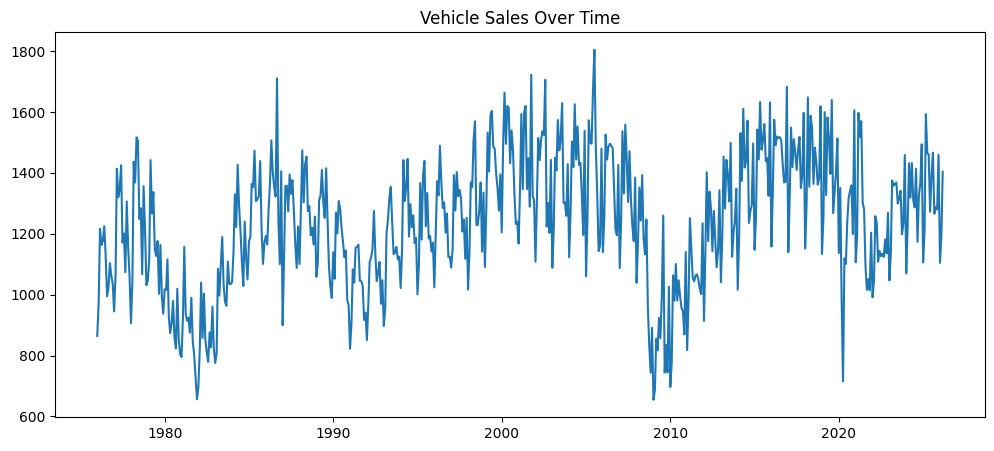

In [34]:
plt.figure(figsize=(12,5))
plt.plot(df['Sales'])
plt.title("Vehicle Sales Over Time")
plt.show()

In [37]:
monthly = df.resample('ME').sum()
quarterly = df.resample('QE').sum()

In [38]:
monthly['RollingMean'] = monthly['Sales'].rolling(window=3).mean()

In [39]:
monthly['Diff'] = monthly['Sales'].diff()

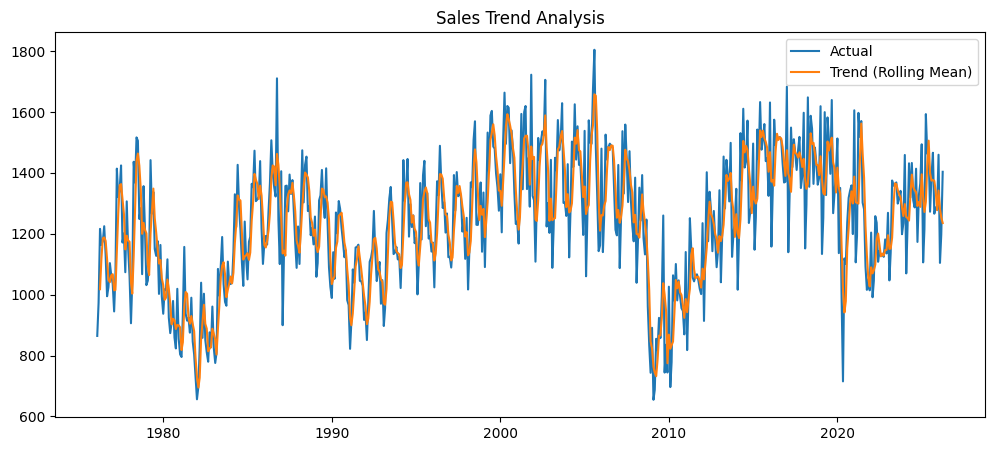

In [40]:
plt.figure(figsize=(12,5))

plt.plot(monthly['Sales'], label='Actual')
plt.plot(monthly['RollingMean'], label='Trend (Rolling Mean)')

plt.legend()
plt.title("Sales Trend Analysis")
plt.show()

In [ ]:
## Key Insights

- Sales show clear trend and seasonal patterns
- Peaks likely correspond to high-demand periods
- Variability suggests external factors influencing demand

In [41]:
train = monthly[:-6]
test = monthly[-6:]

In [42]:
model = ARIMA(train['Sales'], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=6)

In [43]:
mae = mean_absolute_error(test['Sales'], forecast)
print("MAE:", mae)

MAE: 111.31710590625921


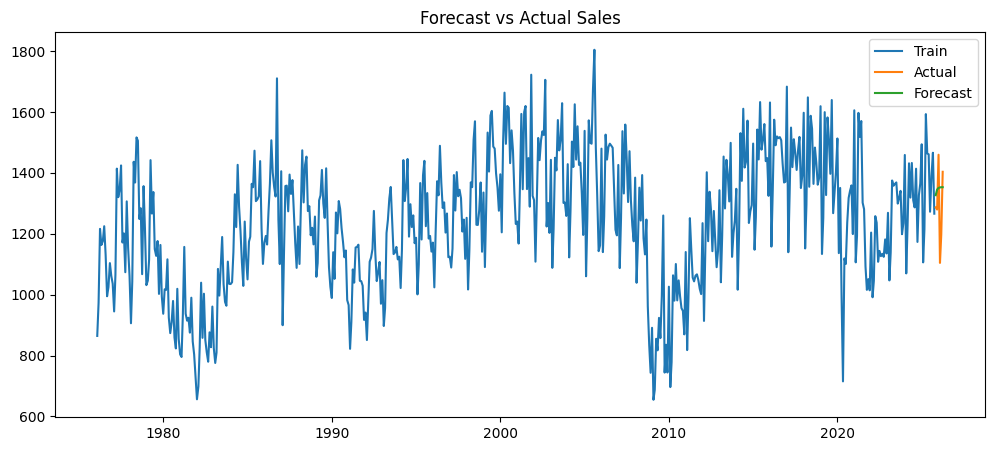

In [44]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.title("Forecast vs Actual Sales")
plt.show()

In [ ]:
## Business Insights

- The model captures overall sales direction reasonably well
- Forecast indicates stable demand over the next 6 months
- Seasonal peaks suggest inventory planning is critical during high-demand periods

## Recommendations

- Increase inventory ahead of peak months
- Align production cycles with demand trends
- Continuously update model with new data for better accuracy

In [ ]:
## Conclusion

This project demonstrates how time series analysis can be used to transform raw sales data into actionable business forecasts.

By applying resampling, rolling averages, and ARIMA modeling, we successfully built a forecasting pipeline that supports data-driven decision-making in vehicle sales planning.

In [ ]:
1. Title & Business Problem
2. Imports
3. Data Loading
4. Cleaning
5. EDA
6. Resampling
7. Feature Engineering
8. Modeling (ARIMA)
9. Evaluation
10. Forecast Visualization
11. Insights
12. Conclusion

In [46]:
!pip install prophet

In [50]:
from prophet import Prophet

# Reset index
prophet_df = monthly.reset_index()

# Rename columns
prophet_df.rename(columns={
    'observation_date': 'ds',
    'Sales': 'y'
}, inplace=True)

prophet_df.head()

,ds,y,RollingMean,Diff
0,1976-01-31,864.6,NaN,NaN
1,1976-02-29,973.3,NaN,108.7
2,1976-03-31,1216.1,1018.000000,242.8
3,1976-04-30,1163.2,1117.533333,-52.9
4,1976-05-31,1176.1,1185.133333,12.9


In [51]:
model_prophet = Prophet()
model_prophet.fit(prophet_df)

16:31:59 - cmdstanpy - INFO - Chain [1] start processing
16:32:00 - cmdstanpy - INFO - Chain [1] done processing


In [86]:
future = model_prophet.make_future_dataframe(periods=6, freq='ME')
forecast_prophet = model_prophet.predict(future)

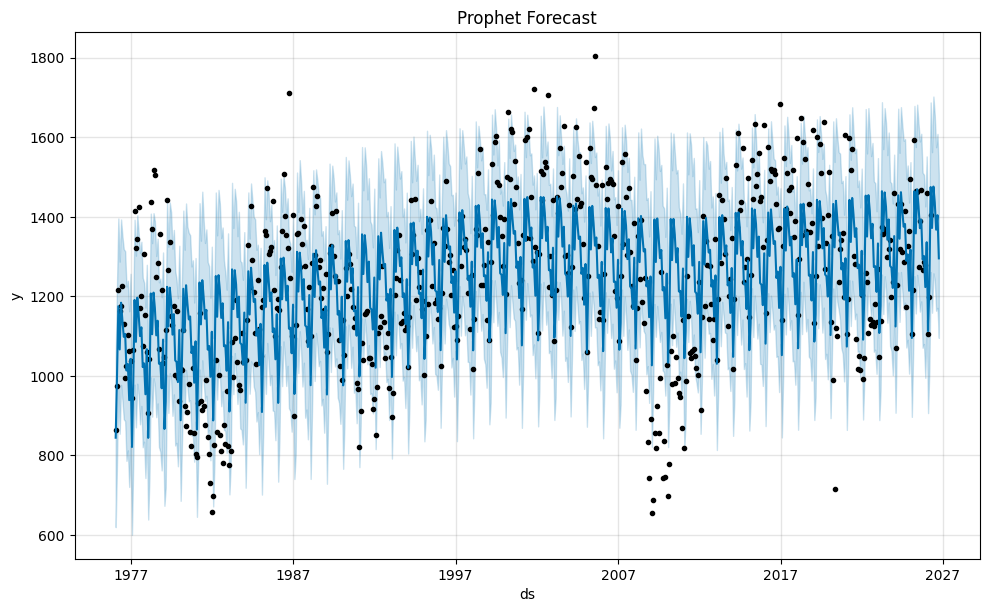

In [87]:
model_prophet.plot(forecast_prophet)
plt.title("Prophet Forecast")
plt.show()

In [88]:
# Align data for comparison
prophet_forecast = forecast_prophet[['ds', 'yhat']].tail(6)
prophet_forecast.set_index('ds', inplace=True)

comparison = pd.DataFrame({
    'Actual': test['Sales'],
    'ARIMA': forecast,
    'Prophet': prophet_forecast['yhat']
})

comparison

,Actual,ARIMA,Prophet
2025-10-31,1286.826,1326.809572,NaN
2025-11-30,1279.640,1345.151069,NaN
2025-12-31,1459.601,1350.685632,NaN
2026-01-31,1104.418,1352.355691,NaN
2026-02-28,1197.916,1352.859633,NaN
2026-03-31,1403.623,1353.011698,NaN
2026-04-30,NaN,NaN,1371.742862
2026-05-31,NaN,NaN,1475.872962
2026-06-30,NaN,NaN,1436.719047
2026-07-31,NaN,NaN,1367.483395


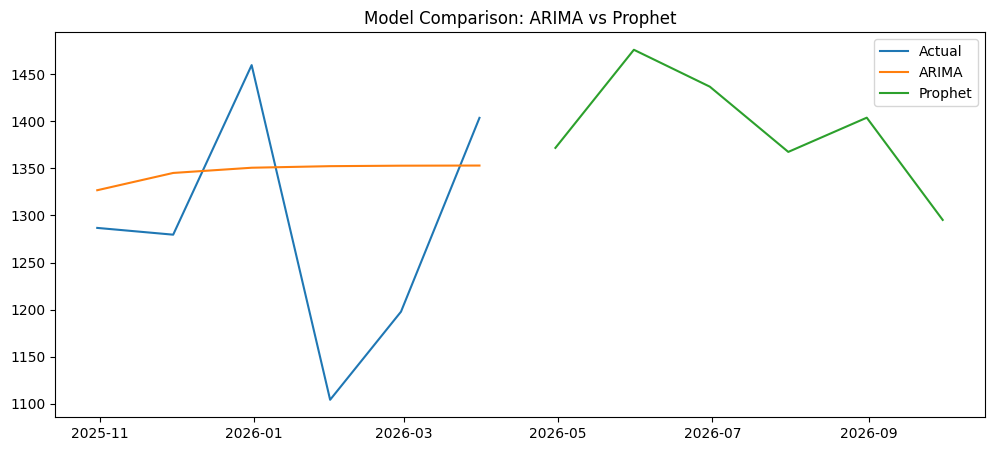

In [89]:
plt.figure(figsize=(12,5))

plt.plot(comparison['Actual'], label='Actual')
plt.plot(comparison['ARIMA'], label='ARIMA')
plt.plot(comparison['Prophet'], label='Prophet')

plt.legend()
plt.title("Model Comparison: ARIMA vs Prophet")
plt.show()

In [90]:
from sklearn.metrics import mean_absolute_error

mae_arima = mean_absolute_error(test['Sales'], forecast)
mae_prophet = mean_absolute_error(test['Sales'], prophet_forecast['yhat'])

print("ARIMA MAE:", mae_arima)
print("Prophet MAE:", mae_prophet)

ARIMA MAE: 111.31710590625921
Prophet MAE: 146.8857887750264


In [91]:
comparison.to_csv("forecast_results.csv")
monthly.to_csv("historical_sales.csv")